# Model Training — Customer Segmentation via KMeans

In this notebook we have `customer_features.csv` (Recency, Frequency, Monetary + bonus features) 
Clustering will be done using KMeans. Steps: Scaling → Optimal K dhoondna → Training → 
Cluster Profiling → Model Save.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/customer_features.csv")
print("Shape:", df.shape)
df.head()

Shape: (93357, 6)


,customer_unique_id,recency_days,frequency,monetary,avg_review_score,avg_delivery_Days
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,5.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4.0,3.0
2,0000f46a3911fa3c0805444483337064,536,1,86.22,3.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,4.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,5.0,13.0


## Step 1: Checking for Outliers

Before scaling, we examine the distributions of Recency, Frequency, and Monetary values—
since we had already observed during EDA that the Monetary feature is heavily right-skewed (with extreme outliers).
This will help us decide whether to use StandardScaler or RobustScaler.

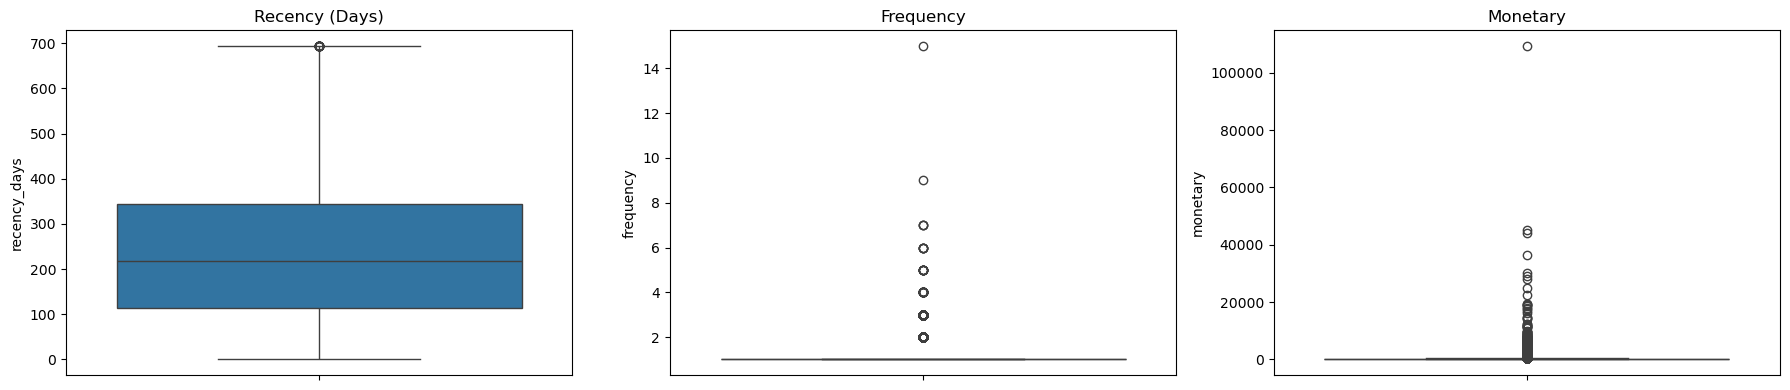

In [3]:
fig, axes = plt.subplots(1,3, figsize=(18,4))

sns.boxplot(y=df["recency_days"], ax=axes[0])
axes[0].set_title("Recency (Days)")

sns.boxplot(y=df["frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=df["monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.savefig("../reports/figures/rfm_boxplots.png")
plt.show()

# Business Insight / Technical Decision:

There are outliers across all three features, particularly in Monetary and Frequency. If we use the standard `StandardScaler`, these outliers will distort the mean and standard deviation, causing the scaled values ​​of the remaining 'normal' customers to become highly compressed—rendering the clustering ineffective. Therefore, we will use `RobustScaler`, which relies on the median and IQR (Interquartile Range) for scaling rather than the mean and standard deviation; consequently, it is less affected by outliers.

## Step 2: Feature Scaling (RobustScaler)

We are using **RobustScaler** instead of StandardScaler due to the presence of outliers.
RobustScaler utilizes the median and IQR (25th–75th percentile), which minimizes the impact of extreme values ​​on scaling—ensuring that the data for typical customers remains distributed in a more meaningful way.

In [4]:
from sklearn.preprocessing import RobustScaler

features_for_clustering = ["recency_days", "frequency", "monetary", "avg_review_score", "avg_delivery_Days"]

X = df[features_for_clustering]

scaler =RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print("Scaled data preview:")
X_scaled_df.head()

Scaled data preview:


,recency_days,frequency,monetary,avg_review_score,avg_delivery_Days
0,-0.461207,0.0,0.207190,0.0,-0.444444
1,-0.448276,0.0,-0.619192,-1.0,-0.777778
2,1.370690,0.0,-0.193934,-2.0,1.666667
3,0.439655,0.0,-0.500828,-1.0,1.111111
4,0.297414,0.0,0.603343,0.0,0.333333


# Important Business/Technical Insight 

The 'Frequency' feature has very low variance because 97% of customers have a frequency of 1. Even after scaling, this feature will contribute less to clustering compared to Recency or Monetary metrics; however, the slight variance that does exist (due to repeat customers) will automatically push them into a separate cluster, which is valuable for the business (identifying loyal customers).


In [5]:
print(X_scaled_df["frequency"].value_counts().head())

frequency
0.0    90556
1.0     2573
2.0      181
3.0       28
4.0        9
Name: count, dtype: int64


## Step 3: Elbow Method — Finding the Optimal K

Before performing K-Means clustering, we need to decide how many clusters (k) to create.
In the Elbow Method, we run K-Means for values ​​of k ranging from 1 to 10 and plot the WCSS (Within-Cluster Sum of Squares / Inertia). The point on the graph where an "elbow" (bend) appears represents the optimal k; adding more clusters beyond this point yields very little improvement.

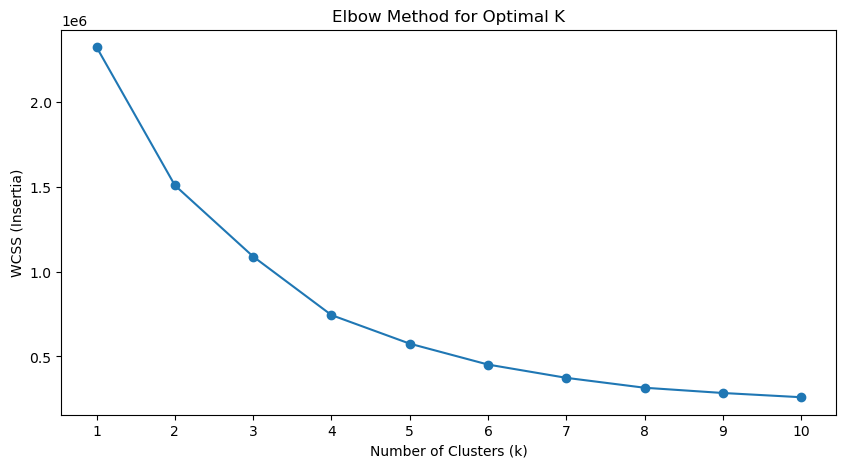

In [6]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_range, wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Insertia)")
plt.xticks(k_range)
plt.savefig("../reports/figures/elbow_method.png")


## Step 4: Silhouette Score — Confirming the Elbow

The Silhouette Score (ranging from -1 to +1) indicates how well-separated the clusters are.
A higher score signifies better clustering. We will use this to confirm or compare the candidate k-values ​​(4, 5) obtained via the Elbow Method.

k=2, Silhouette Score=0.9835
k=3, Silhouette Score=0.8729
k=4, Silhouette Score=0.8381
k=5, Silhouette Score=0.6399
k=6, Silhouette Score=0.4681
k=7, Silhouette Score=0.4728


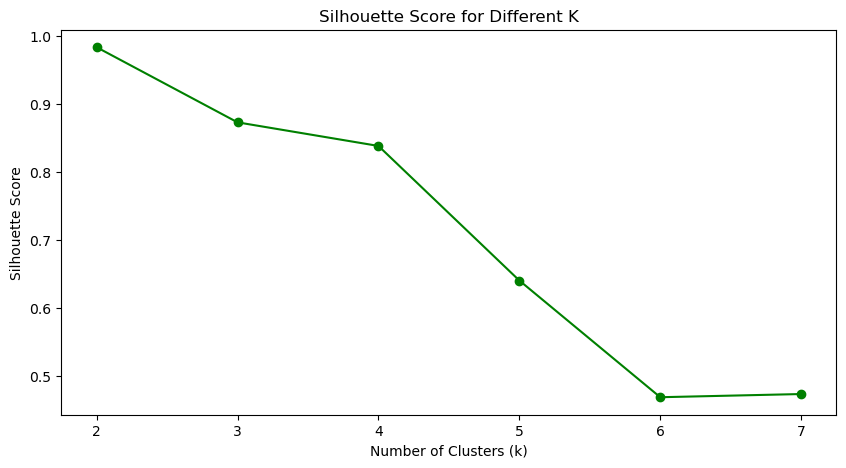

In [7]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 8)  # The silhouette is not defined for k=1, so it starts from 2.

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range_sil, silhouette_scores, marker="o", color="green")
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.savefig("../reports/figures/silhouette_scores.png")
plt.show()

In [8]:
for k in [2, 4, 5]:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    print(f"\nk={k} cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())


k=2 cluster sizes:
0    93335
1       22
Name: count, dtype: int64

k=4 cluster sizes:
0    92047
1       21
2        1
3     1288
Name: count, dtype: int64

k=5 cluster sizes:
0    87744
1       21
2      316
3     5275
4        1
Name: count, dtype: int64


## Step 3.5: Outlier Capping (IQR Method)

Extreme outliers are distorting the K-Means clustering, resulting in the formation of small, business-irrelevant clusters. We will "cap" these outliers using the IQR method (limiting extreme values ​​to a reasonable upper or lower bound) so that the clustering focuses on the actual behavior of the majority of customers.

In [9]:
def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper)

df_capped = df.copy()
for col in ["recency_days", "frequency", "monetary", "avg_delivery_Days"]:
    df_capped[col] = cap_outliers(df_capped[col])

print("Before capping - Monetary max:", df["monetary"].max())
print("After capping - Monetary max:", df_capped["monetary"].max())

Before capping - Monetary max: 109312.64
After capping - Monetary max: 410.855


In [10]:
features_for_clustering = ["recency_days", "frequency", "monetary", "avg_review_score", "avg_delivery_Days"]

X = df_capped[features_for_clustering]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print("Scaled data preview (after capping):")
X_scaled_df.head()

Scaled data preview (after capping):


,recency_days,frequency,monetary,avg_review_score,avg_delivery_Days
0,-0.461207,0.0,0.207190,0.0,-0.444444
1,-0.448276,0.0,-0.619192,-1.0,-0.777778
2,1.370690,0.0,-0.193934,-2.0,1.666667
3,0.439655,0.0,-0.500828,-1.0,1.111111
4,0.297414,0.0,0.603343,0.0,0.333333


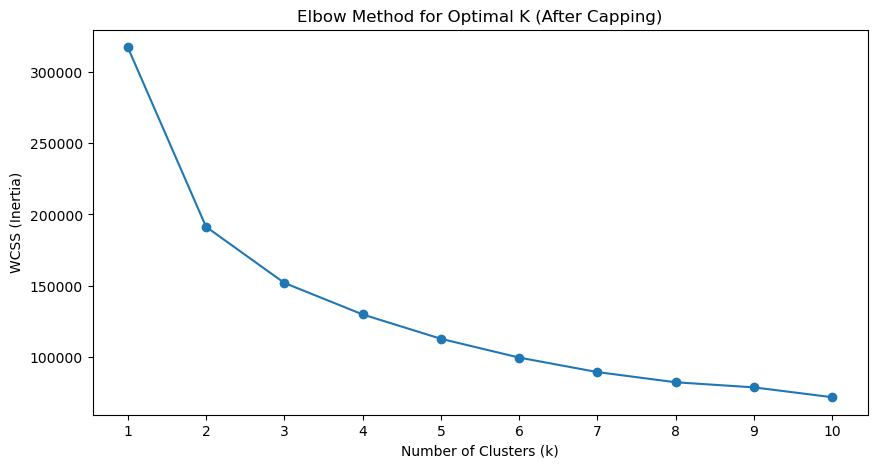

In [11]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker="o")
plt.title("Elbow Method for Optimal K (After Capping)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.savefig("../reports/figures/elbow_method_capped.png")
plt.show()

k=2, Silhouette Score=0.4470
k=3, Silhouette Score=0.3419
k=4, Silhouette Score=0.2630
k=5, Silhouette Score=0.2767
k=6, Silhouette Score=0.2836
k=7, Silhouette Score=0.2833


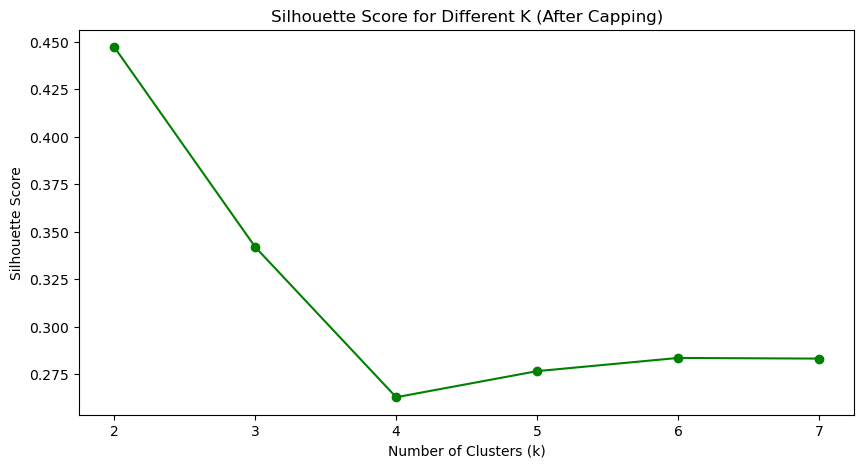

In [12]:
silhouette_scores = []
k_range_sil = range(2, 8)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range_sil, silhouette_scores, marker="o", color="green")
plt.title("Silhouette Score for Different K (After Capping)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.savefig("../reports/figures/silhouette_scores_capped.png")
plt.show()

In [13]:
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    print(f"\nk={k} cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())


k=2 cluster sizes:
0    73780
1    19577
Name: count, dtype: int64

k=3 cluster sizes:
0    16283
1    18062
2    59012
Name: count, dtype: int64

k=4 cluster sizes:
0    31137
1    15309
2    14530
3    32381
Name: count, dtype: int64

k=5 cluster sizes:
0    13816
1    29644
2    11866
3    21975
4    16056
Name: count, dtype: int64


## Step 5: Final KMeans Model (k=4)

Based on Elbow Method, Silhouette Score, and cluster balance analysis k=4 
The final choice is to provide the most balanced cluster sizes and business-interpretable segments.

In [15]:
final_k = 4 
kmeans_final = KMeans(n_clusters=final_k, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the capped DataFrame
df_capped["cluster"] = cluster_labels

print("Cluster sizes:")
print(df_capped["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    31137
1    15309
2    14530
3    32381
Name: count, dtype: int64


## Step 6: Cluster Profiling

By examining the average RFM and behavioral features of each cluster, we will assign business-meaningful names (such as "High Value," "At Risk," etc.)—this is a purely data-driven interpretation.

In [18]:
cluster_profile = df_capped.groupby("cluster")[
    ["recency_days", "frequency", "monetary", "avg_review_score", "avg_delivery_Days"]
].mean().round(2)

cluster_profile["customer_count"] = df_capped["cluster"].value_counts().sort_index()
print(cluster_profile)

         recency_days  frequency  monetary  avg_review_score  \
cluster                                                        
0              353.01        1.0    103.23              4.63   
1              234.81        1.0    170.62              1.64   
2              235.96        1.0    360.75              4.58   
3              126.76        1.0     99.29              4.69   

         avg_delivery_Days  customer_count  
cluster                                     
0                    13.48           31137  
1                    17.07           15309  
2                    11.50           14530  
3                     6.97           32381  


## Step 7: Assign Cluster Names

Each cluster is given a business-meaningful name based on data-driven analysis:
- Cluster 0: Lost/Inactive Customers
- Cluster 1: At Risk/Dissatisfied Customers  
- Cluster 2: High Value Customers
- Cluster 3: Engaged/Recent Customers

In [21]:
cluster_names ={
    0: "Lost/ Inactive",
    1: "At Risk / Dissatisfied",
    2: "High Value",
    3: "Engaged / Recent",
}

df_capped["segment_name"] = df_capped["cluster"].map(cluster_names)

print(df_capped["segment_name"].value_counts())
df_capped[["customer_unique_id", "cluster", "segment_name"]].head(10)

segment_name
Engaged / Recent          32381
Lost/ Inactive            31137
At Risk / Dissatisfied    15309
High Value                14530
Name: count, dtype: int64


,customer_unique_id,cluster,segment_name
0,0000366f3b9a7992bf8c76cfdf3221e2,3,Engaged / Recent
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3,Engaged / Recent
2,0000f46a3911fa3c0805444483337064,1,At Risk / Dissatisfied
3,0000f6ccb0745a6a4b88665a16c9f078,0,Lost/ Inactive
4,0004aac84e0df4da2b147fca70cf8255,0,Lost/ Inactive
5,0004bd2a26a76fe21f786e4fbd80607f,3,Engaged / Recent
6,00050ab1314c0e55a6ca13cf7181fecf,3,Engaged / Recent
7,00053a61a98854899e70ed204dd4bafe,1,At Risk / Dissatisfied
8,0005e1862207bf6ccc02e4228effd9a0,0,Lost/ Inactive
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,At Risk / Dissatisfied


In [22]:
import joblib

# Model save 
joblib.dump(kmeans_final, "../models/saved_models/customer_segment_predictor.pkl")

# Save the scaler (crucial – the same scaling is required when making predictions for new customers)
joblib.dump(scaler, "../models/saved_models/scaler.pkl")

# Save feature columns (to remember the order)
joblib.dump(features_for_clustering, "../models/saved_models/feature_columns.pkl")

# Save Cluster names 
joblib.dump(cluster_names, "../models/saved_models/cluster_names.pkl")

print("Model, scaler, aur metadata saved successfully!")

Model, scaler, aur metadata saved successfully!


In [23]:
df_capped.to_csv("../data/processed/customer_segments.csv", index=False)
print("Final segmented data saved!")
print("Shape:", df_capped.shape)

Final segmented data saved!
Shape: (93357, 8)
